In [151]:
import sys
print(f"Success! Using Environment: {sys.prefix}")

Success! Using Environment: /home/sagemaker-user/Language-Translation/mnit_env


In [152]:
!nvidia-smi

Mon Apr  6 11:18:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   35C    P0             32W /   70W |    2889MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [153]:
import torch
import pickle
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


import os
import re
import shutil
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import gensim.downloader as api
from collections import Counter

In [154]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [155]:
import dagshub
import mlflow
dagshub.init(repo_owner='thanwal', repo_name='Language-Translation', mlflow=True)

Initialized MLflow to track repo "thanwal/Language-Translation"

Repository thanwal/Language-Translation initialized!

Load Dataset from drive or upload to drive re-run

In [156]:
df = pd.read_csv('data/Cleaned_Sentence_pairs_Full.csv')
print(df.head())

                                    English  \
0                          muiriel is now .   
1                          muiriel is now .   
2  education in this world disappoints me .   
3                        that wont happen .   
4                              i miss you .   

                                          Hindi  
0             म्यूरियल अब बीस साल की हो गई है ।  
1                   म्यूरियल अब बीस साल की है ।  
2  मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ ।  
3                              वैसा नहीं होगा ।  
4                 मुझें तुम्हारी याद आ रही है ।  


In [157]:
def tokenize(text):
    return text.split()

special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
MIN_FREQ = 1
embedding_dim = 300

Function to create English embeddings

In [158]:
def create_English_embedding(df):
    English_train = df['English']
    English_word2vec = api.load('word2vec-google-news-300')

    English_train_sentences = [tokenize(x) for x in English_train]
    print(len(English_train_sentences))

    English_counter = Counter()
    for s in English_train_sentences:
        English_counter.update(s)

    English_valid_words = [w for w, count in English_counter.most_common() if count >= MIN_FREQ]

    English_word2idx = {tok: idx for idx, tok in enumerate(special_tokens)}
    for word in English_valid_words:
        English_word2idx[word] = len(English_word2idx)

    English_idx2word = {idx: word for word, idx in English_word2idx.items()}

    English_embedding_matrix = [np.zeros(embedding_dim), 
                                np.random.normal(scale=0.6, size=(embedding_dim,)),
                                np.zeros(embedding_dim),
                                np.zeros(embedding_dim)]

    for word in English_valid_words:
        if word in English_word2vec:
            English_embedding_matrix.append(English_word2vec[word])
        else:
            English_embedding_matrix.append(np.random.normal(scale=0.6, size=(embedding_dim,)))

    English_embedding_matrix = torch.from_numpy(np.array(English_embedding_matrix)).float()

    if len(English_embedding_matrix) == len(English_word2idx) == len(English_idx2word):
        print(len(English_word2idx))
        print(English_embedding_matrix.shape)

    del English_word2vec 
    gc.collect()

    return English_embedding_matrix, English_word2idx, English_idx2word

Function to create Hindi embeddings

In [159]:
def create_Hindi_embedding(df):
    Hindi_train = df['Hindi']
    Hindi_word2vec = api.load('fasttext-wiki-news-subwords-300')
    
    Hindi_train_sentences = [tokenize(x) for x in Hindi_train]
    print(len(Hindi_train_sentences))

    Hindi_counter = Counter()

    for s in Hindi_train_sentences:
        Hindi_counter.update(s)

    Hindi_valid_words = [w for w, count in Hindi_counter.most_common() if count >= MIN_FREQ]

    Hindi_word2idx={tok: idx for idx, tok in enumerate(special_tokens)}
    for word in Hindi_valid_words:
        Hindi_word2idx[word] = len(Hindi_word2idx)

    Hindi_idx2word = {idx: word for word, idx in Hindi_word2idx.items()}

    Hindi_embedding_matrix = [np.zeros(embedding_dim),
                            np.random.normal(scale=0.6, size=(embedding_dim,)),
                            np.zeros(embedding_dim),
                            np.zeros(embedding_dim)]

    for word in Hindi_valid_words:
        if word in Hindi_word2vec:
            Hindi_embedding_matrix.append(Hindi_word2vec[word])
        else:
            Hindi_embedding_matrix.append(np.random.normal(scale=0.6, size=(embedding_dim,)))

    Hindi_embedding_matrix = torch.from_numpy(np.array(Hindi_embedding_matrix)).float()

    if len(Hindi_embedding_matrix)==len(Hindi_word2idx)==len(Hindi_idx2word):
        print(len(Hindi_word2idx))
        print(Hindi_embedding_matrix.shape)

    del Hindi_word2vec 
    gc.collect()

    return Hindi_embedding_matrix, Hindi_word2idx, Hindi_idx2word

Load saved Ebedding or create and save for re-run to drive 

In [160]:
saves_path = 'saves'
if os.path.exists(saves_path):
    English_embedding_matrix = torch.load(os.path.join(saves_path, 'eng_emb.pt'))
    Hindi_embedding_matrix = torch.load(os.path.join(saves_path, 'hin_emb.pt'))

    with open(os.path.join(saves_path, 'eng_word2idx.pkl'), 'rb') as f:
        English_word2idx = pickle.load(f)

    with open(os.path.join(saves_path, 'hin_word2idx.pkl'), 'rb') as f:
        Hindi_word2idx = pickle.load(f)

    with open(os.path.join(saves_path, 'eng_idx2word.pkl'), 'rb') as f:
        English_idx2word = pickle.load(f)

    with open(os.path.join(saves_path, 'hin_idx2word.pkl'), 'rb') as f:
        Hindi_idx2word = pickle.load(f)

    print("All files loaded successfully from local directory.")

else:
    English_embedding_matrix, English_word2idx, English_idx2word = create_English_embedding(df)
    Hindi_embedding_matrix, Hindi_word2idx, Hindi_idx2word = create_Hindi_embedding(df)

    os.makedirs(saves_path, exist_ok=True)

    torch.save(English_embedding_matrix, os.path.join(saves_path, 'eng_emb.pt'))
    torch.save(Hindi_embedding_matrix, os.path.join(saves_path, 'hin_emb.pt'))

    with open(os.path.join(saves_path, 'eng_word2idx.pkl'), 'wb') as f:
        pickle.dump(English_word2idx, f)

    with open(os.path.join(saves_path, 'hin_word2idx.pkl'), 'wb') as f:
        pickle.dump(Hindi_word2idx, f)

    with open(os.path.join(saves_path, 'eng_idx2word.pkl'), 'wb') as f:
        pickle.dump(English_idx2word, f)

    with open(os.path.join(saves_path, 'hin_idx2word.pkl'), 'wb') as f:
        pickle.dump(Hindi_idx2word, f)

    print(f"All files saved successfully to: {os.path.abspath(saves_path)}")

All files loaded successfully from local directory.


/tmp/ipykernel_458/927472304.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  English_embedding_matrix = torch.load(os.path.join(saves_path, 'eng_emb.pt'))
/tmp/ipykernel

Split data into Train, Test, Val

In [161]:
df_train_val, df_test = train_test_split(df, test_size=0.10, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)

finding max lenght for data sample

99% of English sentences are shorter than: 28.0
99% of Hindi sentences are shorter than: 28.0


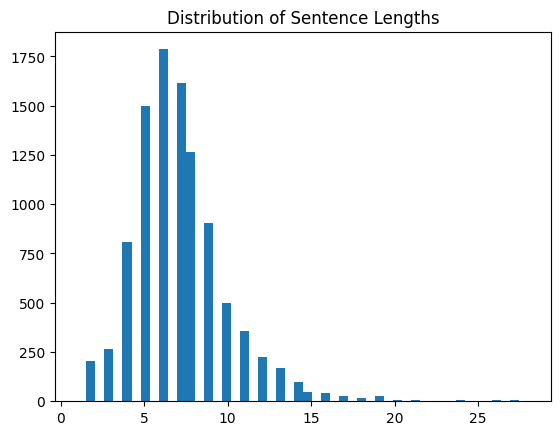

Max Len is 30


In [162]:
English_train = df_train['English']
English_train = df_train['Hindi']

eng_lengths = [len(tokenize(s)) for s in English_train]
hin_lengths = [len(tokenize(s)) for s in English_train]


max_len=int(max(np.percentile(eng_lengths, 100),np.percentile(hin_lengths, 100))+2)

print(f"99% of English sentences are shorter than: {np.percentile(eng_lengths, 100)}")
print(f"99% of Hindi sentences are shorter than: {np.percentile(hin_lengths, 100)}")

plt.hist(eng_lengths, bins=50)
plt.title("Distribution of Sentence Lengths")
plt.show()

print(f"Max Len is {max_len}")

Create custom dataset

In [163]:
class TranslationDataset(Dataset):
    def __init__(self, df, English_word2idx, Hindi_word2idx, max_len=20):
        self.df = df
        self.English_word2idx = English_word2idx
        self.Hind_word2idx = Hindi_word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def preprocess(self, text, word2idx):
        tokens = tokenize(text)
        indices = [word2idx.get(tok, 1) for tok in tokens]
        indices = [2] + indices + [3]

        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        return torch.tensor(indices, dtype=torch.long)

    def __getitem__(self, idx):
        english_text = self.df.iloc[idx]['English']
        hindi_text = self.df.iloc[idx]['Hindi']

        English_tensor = self.preprocess(english_text, self.English_word2idx)
        Hindi_tensor = self.preprocess(hindi_text, self.Hind_word2idx)

        return English_tensor, Hindi_tensor

Loading data into DataLoaders

In [164]:
BATCH_SIZE=128

train_dataset = TranslationDataset(df_train, English_word2idx, Hindi_word2idx, max_len)
val_dataset = TranslationDataset(df_val, English_word2idx, Hindi_word2idx, max_len)
test_dataset = TranslationDataset(df_test, English_word2idx, Hindi_word2idx, max_len)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Varifying that DataLoader and Custom dataset is working fine

In [165]:
English_batch, Hindi_batch = next(iter(train_loader))

print(f"English Batch Shape: {English_batch.shape}")
print(f"Hindi Batch Shape: {Hindi_batch.shape}")

first_sentence = English_batch[0].tolist()
decoded = [English_idx2word.get(idx, '<UNK>') for idx in first_sentence]
print("\nFirst English Sentence in Batch:")
print(" ".join(decoded))

English Batch Shape: torch.Size([128, 30])
Hindi Batch Shape: torch.Size([128, 30])

First English Sentence in Batch:
<SOS> thats too small to fit on your head . <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>


Encoder Unit

In [166]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=30):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x



Seq2Seq Model

In [ ]:
class EngHiTransformer(nn.Module):
    def __init__(self, en_vocab_size, hi_vocab_size, emb_dim=300, nhead=6, num_layers=6):
        super(EngHiTransformer, self).__init__()
        
        self.emb_dim = emb_dim
        
        self.src_embedding = nn.Embedding(en_vocab_size, emb_dim)
        self.tgt_embedding = nn.Embedding(hi_vocab_size, emb_dim)
        
        self.pos_encoder = PositionalEncoding(emb_dim, max_len=30)
        
        self.transformer = nn.Transformer(
            d_model=emb_dim, 
            nhead=nhead, 
            num_encoder_layers=num_layers, 
            num_decoder_layers=num_layers,
            dim_feedforward=2048,
            dropout=0.1,
            batch_first=True
        )
        
        self.fc_out = nn.Linear(emb_dim, hi_vocab_size)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, 
                src_padding_mask=None, tgt_padding_mask=None, 
                memory_key_padding_mask=None):
        
        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.emb_dim))
        tgt_emb = self.pos_encoder(self.tgt_embedding(tgt) * math.sqrt(self.emb_dim))
        
        output = self.transformer(
            src_emb, 
            tgt_emb, 
            src_mask=src_mask, 
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        
        return self.fc_out(output)

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

In [168]:
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='best_model.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [169]:
def calculate_accuracy(preds, y, pad_idx):
    top_preds = preds.argmax(1, keepdim=True).squeeze(1)
    
    correct = top_preds.eq(y)
    
    mask = (y != pad_idx)
    correct = correct & mask
    
    accuracy = correct.sum().float() / mask.sum().float()
    return accuracy

In [170]:
def evaluate(model, val_loader, criterion, pad_idx=0):
    model.eval() 
    epoch_loss = 0
    epoch_acc = 0
    
    with torch.no_grad(): 
        for English_batch, Hindi_batch in val_loader:
            English_batch = English_batch.to(device)
            Hindi_batch = Hindi_batch.to(device)
            
            tgt_input = Hindi_batch[:, :-1]
            tgt_out = Hindi_batch[:, 1:]

            tgt_seq_len = tgt_input.shape[1]
            tgt_mask = model.generate_square_subsequent_mask(tgt_seq_len).to(device)
            
            output = model(English_batch, tgt_input, tgt_mask=tgt_mask) 
            
            output_dim = output.shape[-1]
            output = output.reshape(-1, output_dim)
            tgt_out = tgt_out.reshape(-1)
            
            loss = criterion(output, tgt_out)
            acc = calculate_accuracy(output, tgt_out, pad_idx)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
    return epoch_loss / len(val_loader), epoch_acc / len(val_loader)

Traning Loop

In [171]:
EMB_DIM = 300
HIDDEN_DIM = 512 
NUM_LAYERS = 8
N_HEADS = 6
DROPOUT = 0.1
LR = 0.0001
EPOCHS = 50
CLIP = 1
PAD_IDX = 0

model = EngHiTransformer(
    en_vocab_size=len(English_word2idx), 
    hi_vocab_size=len(Hindi_word2idx), 
    emb_dim=EMB_DIM, 
    nhead=N_HEADS, 
    num_layers=NUM_LAYERS
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def create_masks(src, tgt, pad_idx):
    tgt_seq_len = tgt.shape[1]
    tgt_mask = model.generate_square_subsequent_mask(tgt_seq_len).to(device)
    
    src_padding_mask = (src == pad_idx)
    tgt_padding_mask = (tgt == pad_idx)
    
    return tgt_mask, src_padding_mask, tgt_padding_mask

mlflow.set_experiment("Language_Translation_Transformer_Base")

early_stopping = EarlyStopping(patience=10, verbose=True, path='transformer_best.pt')

with mlflow.start_run(run_name="Transformer_v2_300d_Word2Vec"):
    mlflow.log_params({
        "epochs": EPOCHS,
        "emb_dim": EMB_DIM,
        "n_heads": N_HEADS,
        "num_layers": NUM_LAYERS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR
    })

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0

        for English_batch, Hindi_batch in train_loader:
            English_batch = English_batch.to(device)
            Hindi_batch = Hindi_batch.to(device)

            tgt_input = Hindi_batch[:, :-1]
            tgt_out = Hindi_batch[:, 1:]

            tgt_mask, src_pad_mask, tgt_pad_mask = create_masks(English_batch, tgt_input, PAD_IDX)

            optimizer.zero_grad()
            
            output = model(English_batch, tgt_input, tgt_mask=tgt_mask) 

            output_dim = output.shape[-1]
            output = output.reshape(-1, output_dim)
            tgt_out = tgt_out.reshape(-1)

            loss = criterion(output, tgt_out)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += calculate_accuracy(output, tgt_out, PAD_IDX).item()

        train_loss = epoch_loss / len(train_loader)
        train_acc = epoch_acc / len(train_loader)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        gpu_peak_gb = torch.cuda.max_memory_allocated(device) / (1024**3) if torch.cuda.is_available() else 0.0
        if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats(device)

        early_stopping(val_loss, model)
        
        if early_stopping.early_stop:
            print("Early stopping triggered! Training stopped.")
            mlflow.log_param("stopped_epoch", epoch)
            break

        mlflow.log_metrics({"train_loss": train_loss, "val_acc": val_acc}, step=epoch)

        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | GPU Peak: {gpu_peak_gb:.2f}GB")

    
    model.load_state_dict(torch.load('transformer_best.pt'))
    mlflow.pytorch.log_model(model, "best_transformer_model")


Validation loss decreased (inf --> 5.311334). Saving model...
Epoch 01 | Train Loss: 6.4163 | Train Acc: 0.2040 | Val Acc: 0.2822 | GPU Peak: 3.00GB
Validation loss decreased (5.311334 --> 4.805285). Saving model...
Epoch 02 | Train Loss: 4.9936 | Train Acc: 0.2981 | Val Acc: 0.3154 | GPU Peak: 3.00GB
Validation loss decreased (4.805285 --> 4.608166). Saving model...
Epoch 03 | Train Loss: 4.6471 | Train Acc: 0.3288 | Val Acc: 0.3388 | GPU Peak: 3.00GB
Validation loss decreased (4.608166 --> 4.440751). Saving model...
Epoch 04 | Train Loss: 4.4213 | Train Acc: 0.3523 | Val Acc: 0.3597 | GPU Peak: 3.00GB
Validation loss decreased (4.440751 --> 4.282458). Saving model...
Epoch 05 | Train Loss: 4.2147 | Train Acc: 0.3744 | Val Acc: 0.3773 | GPU Peak: 3.00GB
Validation loss decreased (4.282458 --> 4.172169). Saving model...
Epoch 06 | Train Loss: 4.0460 | Train Acc: 0.3913 | Val Acc: 0.3900 | GPU Peak: 3.00GB
Validation loss decreased (4.172169 --> 4.068380). Saving model...
Epoch 07 | Tra

/tmp/ipykernel_458/1378821325.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('transformer_best.pt'))
2026/04/06 11:39:35 WARNING mlflo

Epoch 50 | Train Loss: 0.5888 | Train Acc: 0.8823 | Val Acc: 0.5617 | GPU Peak: 3.00GB


2026/04/06 11:39:37 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/06 11:39:38 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/06 11:39:42 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it

🏃 View run Transformer_v2_300d_Word2Vec at: https://dagshub.com/thanwal/Language-Translation.mlflow/#/experiments/3/runs/e202d52dc916450b90f3513ea7f9021f
🧪 View experiment at: https://dagshub.com/thanwal/Language-Translation.mlflow/#/experiments/3


In [172]:
def translate_sentence(sentence, model, English_word2idx, Hindi_idx2word, device, max_len=30):
    model.eval()
    
    if isinstance(sentence, str):
        tokens = [word.lower() for word in sentence.split()]
    else:
        tokens = [word.lower() for word in sentence]
        
    indices = [English_word2idx.get(tok, 1) for tok in tokens]
    indices = [2] + indices + [3] 
    
    src_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        src_emb = model.pos_encoder(model.src_embedding(src_tensor) * math.sqrt(model.emb_dim))
        memory = model.transformer.encoder(src_emb)
  
    Hindi_indexes = [2] 
    
    for i in range(max_len):
        tgt_tensor = torch.tensor(Hindi_indexes, dtype=torch.long).unsqueeze(0).to(device)
        
        tgt_mask = model.generate_square_subsequent_mask(tgt_tensor.size(1)).to(device)
        
        with torch.no_grad():
            tgt_emb = model.pos_encoder(model.tgt_embedding(tgt_tensor) * math.sqrt(model.emb_dim))
            output = model.transformer.decoder(tgt_emb, memory, tgt_mask=tgt_mask)
            
            logits = model.fc_out(output[:, -1, :])
            pred_token = logits.argmax(1).item()
            
        Hindi_indexes.append(pred_token)
        
        if pred_token == 3:
            break
            
    trg_tokens = [Hindi_idx2word.get(i, '<UNK>') for i in Hindi_indexes]
    
    return " ".join(trg_tokens[1:-1])

In [173]:
test_indices = random.sample(range(len(df_test)), 10)

print(f"{'TRANSFORMER INFERENCE':^50}")
print("=" * 50)

for idx in test_indices:
    src_sentence = df_test.iloc[idx]['English']
    true_translation = df_test.iloc[idx]['Hindi']
    
    model_prediction = translate_sentence(
        src_sentence, model, English_word2idx, Hindi_idx2word, device
    )
    
    print(f"English: {src_sentence}")
    print(f"Actual : {true_translation}")
    print(f"Model  : {model_prediction}")
    print("-" * 50)

              TRANSFORMER INFERENCE               
English: we won the lottery .
Actual : हम लॉटरी जीते ।
Model  : अब तक अपने बेटे को ले दें जब में सबसे ज़्यादा नाम में जाकर क्या कर रहे हैं ।
--------------------------------------------------
English: i want a guitar .
Actual : मुझे गिटार चाहिए ।
Model  : मुझे किसी भी कार का एक कार करना अच्छा लगता है . मैं कार कार जा रहा हूँ .
--------------------------------------------------
English: let me give you a piece of advice .
Actual : मैं तुम्हें एक बात की सलाह देता हूँ ।
Model  : अब मुझे अपनी भाषा सीखने में अच्छी तरह से कोई परेशानी नहीं है .
--------------------------------------------------
English: i love you .
Actual : मुझे तुमसे प्यार है ।
Model  : मैं तुम्हारे पिता को अच्छी तरह से पहले अपने परिवार में नहीं जानता हूँ । तुम्हें कोई चाहता हूं । तुम्हें कोई भी मेरे साथ ले जा रहा है
--------------------------------------------------
English: tom stayed in bed all day watching tv .
Actual : टॉम पूरा दिन टीवी देखते बिस्तर पर पड़े रहें ।
Mode